# Pilot ECIS Data Analysis
This notebook loads pilot ECIS data, filters to a single frequency (500 Hz), normalizes the signal to baseline, compares technical replicates, and extracts simple quantitative features from the ECIS response.

In [4]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 1. Locate and Load the Pilot ECIS File
First, check the current working directory and confirm where the ECIS CSV files are stored.

In [5]:
print("Current working directory:")
print(os.getcwd())

print("\nFiles in current directory:")
print(os.listdir())

Current working directory:
/Users/danyaleyva/Desktop/Project ECIS/notebooks

Files in current directory:
['ECIS_analysis.ipynb', '.ipynb_checkpoints']


## 2. Define File Paths
Set the file paths for the pilot ECIS replicate files.  
Update the folder path below if your CSV files are stored somewhere else.

In [6]:
# Change this path if your files are in a different folder
base_path = Path("../data/ecis_simulated_pilot (1)")

file_r1 = base_path / "pilot_sim_001_C1_R1.csv"
file_r2 = base_path / "pilot_sim_001_C1_R2.csv"
file_r3 = base_path / "pilot_sim_001_C1_R3.csv"

print(file_r1)
print(file_r2)
print(file_r3)

../data/ecis_simulated_pilot (1)/pilot_sim_001_C1_R1.csv
../data/ecis_simulated_pilot (1)/pilot_sim_001_C1_R2.csv
../data/ecis_simulated_pilot (1)/pilot_sim_001_C1_R3.csv


## 3. Load One Pilot ECIS File
Load one replicate first to inspect the dataset structure.

In [7]:
df = pd.read_csv(file_r1)
df.head()

,Time_min,Frequency_Hz,Impedance_Magnitude
0,0,500,862.929851
1,5,500,862.252284
2,10,500,873.224971
3,15,500,874.821405
4,20,500,865.888778


## 4. Plot the Raw ECIS Signal
Plot the raw impedance magnitude over time before filtering by frequency.

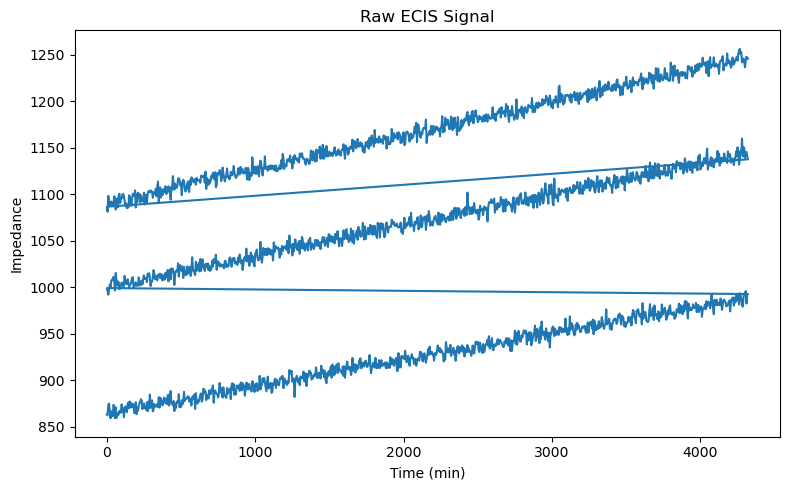

In [8]:
plt.figure(figsize=(8, 5))
plt.plot(df["Time_min"], df["Impedance_Magnitude"])

plt.xlabel("Time (min)")
plt.ylabel("Impedance")
plt.title("Raw ECIS Signal")
plt.tight_layout()
plt.show()

## 5. Filter to 500 Hz
ECIS data contain multiple frequencies. For this initial pilot analysis, we focus on the 500 Hz signal.

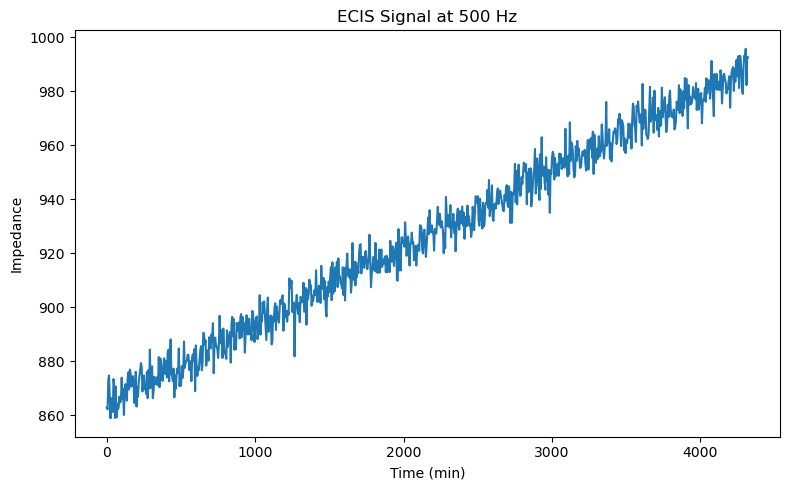

In [9]:
df_500 = df[df["Frequency_Hz"] == 500].copy()

plt.figure(figsize=(8, 5))
plt.plot(df_500["Time_min"], df_500["Impedance_Magnitude"])

plt.xlabel("Time (min)")
plt.ylabel("Impedance")
plt.title("ECIS Signal at 500 Hz")
plt.tight_layout()
plt.show()

## 6. Normalize the ECIS Signal to Baseline
Normalize the 500 Hz impedance signal using the first recorded value as the baseline so the curve begins near 1.0.

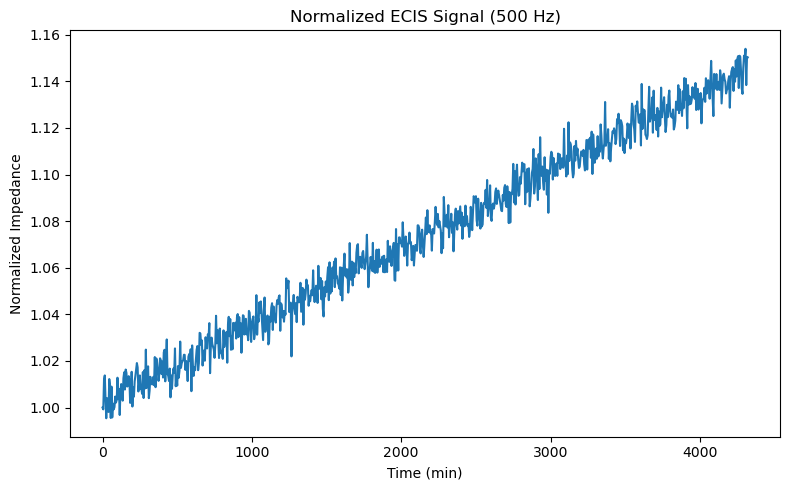

In [10]:
baseline = df_500["Impedance_Magnitude"].iloc[0]
df_500["Normalized"] = df_500["Impedance_Magnitude"] / baseline

plt.figure(figsize=(8, 5))
plt.plot(df_500["Time_min"], df_500["Normalized"])

plt.xlabel("Time (min)")
plt.ylabel("Normalized Impedance")
plt.title("Normalized ECIS Signal (500 Hz)")
plt.tight_layout()
plt.show()

## 7. Compare Technical Replicates
Load replicates R1, R2, and R3, normalize each trace, and compare them on the same plot.

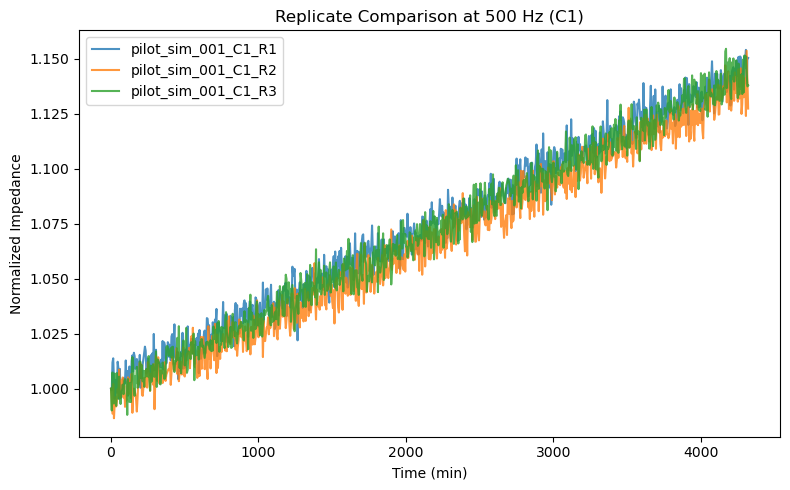

In [11]:
files = [file_r1, file_r2, file_r3]

plt.figure(figsize=(8, 5))

for file in files:
    df_rep = pd.read_csv(file)
    df_rep_500 = df_rep[df_rep["Frequency_Hz"] == 500].copy()

    baseline = df_rep_500["Impedance_Magnitude"].iloc[0]
    df_rep_500["Normalized"] = df_rep_500["Impedance_Magnitude"] / baseline

    plt.plot(df_rep_500["Time_min"], df_rep_500["Normalized"], alpha=0.8, label=file.stem)

plt.xlabel("Time (min)")
plt.ylabel("Normalized Impedance")
plt.title("Replicate Comparison at 500 Hz (C1)")
plt.legend()
plt.tight_layout()
plt.show()

## 8. Compute Mean and Standard Deviation Across Replicates
Calculate the average normalized ECIS response and variability across the three technical replicates.

In [12]:
replicates = []

for file in files:
    df_rep = pd.read_csv(file)
    df_rep_500 = df_rep[df_rep["Frequency_Hz"] == 500].copy()

    baseline = df_rep_500["Impedance_Magnitude"].iloc[0]
    norm = df_rep_500["Impedance_Magnitude"] / baseline

    replicates.append(norm.values)

replicates = np.array(replicates)

mean_signal = replicates.mean(axis=0)
std_signal = replicates.std(axis=0)

time = df_rep_500["Time_min"].values

## 9. Plot the Mean ECIS Response with Variability
Visualize the mean normalized impedance curve with a shaded band representing plus/minus one standard deviation.

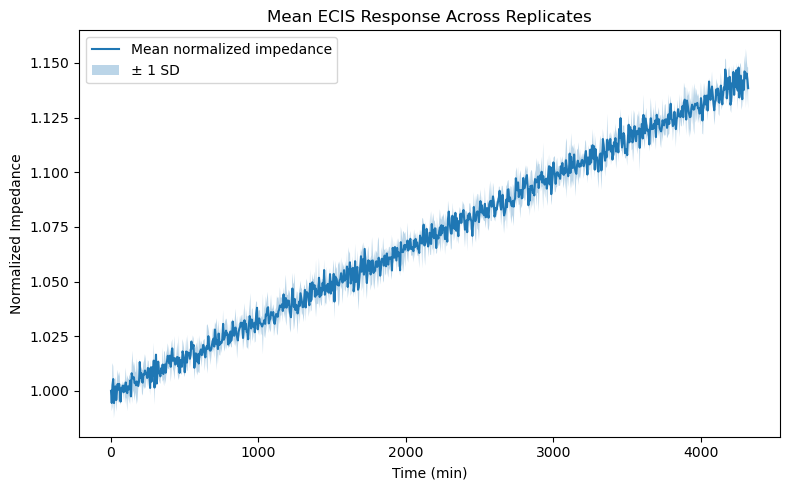

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(time, mean_signal, label="Mean normalized impedance")
plt.fill_between(
    time,
    mean_signal - std_signal,
    mean_signal + std_signal,
    alpha=0.3,
    label="± 1 SD"
)

plt.xlabel("Time (min)")
plt.ylabel("Normalized Impedance")
plt.title("Mean ECIS Response Across Replicates")
plt.legend()
plt.tight_layout()
plt.show()

## 10. Assign the Experimental Condition
Label this pilot dataset as the control condition for organized feature tracking.

In [14]:
condition_name = "Control"

## 11. Extract Simple Quantitative Features
Extract basic ECIS features from the normalized signal:
- maximum normalized impedance
- time of maximum impedance
- approximate growth slope

In [15]:
max_impedance = df_500["Normalized"].max()
time_of_max = df_500.loc[df_500["Normalized"].idxmax(), "Time_min"]

slope = (
    df_500["Normalized"].iloc[-1] - df_500["Normalized"].iloc[0]
) / (
    df_500["Time_min"].iloc[-1] - df_500["Time_min"].iloc[0]
)

print("Maximum normalized impedance:", max_impedance)
print("Time of maximum impedance:", time_of_max)
print("Approximate growth slope:", slope)

Maximum normalized impedance: 1.1539446700084526
Time of maximum impedance: 4305
Approximate growth slope: 3.4787186073399857e-05


## 12. Store Extracted Features in a Results Table
Organize the extracted values into a small summary table for later comparison across conditions.

In [16]:
results = pd.DataFrame({
    "Condition": [condition_name],
    "Max_Impedance": [max_impedance],
    "Time_of_Max": [time_of_max],
    "Slope": [slope]
})

results

,Condition,Max_Impedance,Time_of_Max,Slope
0,Control,1.153945,4305,0.000035


## 13. Plot a Preliminary Feature Summary
Create a simple summary plot for the current condition. This will be more useful once additional conditions are added.

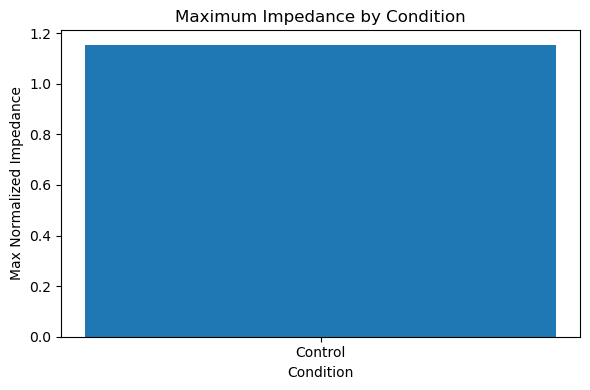

In [17]:
plt.figure(figsize=(6, 4))
plt.bar(results["Condition"], results["Max_Impedance"])

plt.xlabel("Condition")
plt.ylabel("Max Normalized Impedance")
plt.title("Maximum Impedance by Condition")
plt.tight_layout()
plt.show()

## 14. Interpretation
The pilot ECIS datasets were successfully loaded and processed in Python using JupyterLab. The signals were filtered to a single frequency of 500 Hz and normalized to baseline to enable direct comparison across wells.

Replicate comparison across R1–R3 showed relatively consistent impedance trajectories with low variability, suggesting stable signal acquisition during the pilot experiment.

Simple quantitative features, including maximum normalized impedance, time to maximum response, and approximate slope, were extracted successfully. These results provide an initial baseline for later comparisons across experimental conditions.

At this stage, the preprocessing and pilot replicate, check pipeline is functioning correctly.

## 15. Next Step
The next stage of analysis is to expand beyond a single pilot condition and compare multiple ECIS conditions using the same preprocessing pipeline. This will include analyzing additional wells, summarizing features across conditions, and later extending the analysis to richer multi-frequency and model-based ECIS interpretation.

## 16. Load Metadata for All Pilot Wells
This section loads the pilot metadata so all wells can be analyzed together instead of only one control condition.

In [19]:
metadata = pd.read_csv("../data/ecis_simulated_pilot (1)/ecis_metadata.csv")
metadata

,run_id,well_id,file_path,dose_A,dose_B,lag_hr,order,time_unit
0,pilot_sim_001,C1_R1,pilot_sim_001_C1_R1.csv,0,0,0,A_then_B,min
1,pilot_sim_001,C1_R2,pilot_sim_001_C1_R2.csv,0,0,0,A_then_B,min
2,pilot_sim_001,C1_R3,pilot_sim_001_C1_R3.csv,0,0,0,A_then_B,min
3,pilot_sim_001,C2_R1,pilot_sim_001_C2_R1.csv,10,0,0,A_then_B,min
4,pilot_sim_001,C2_R2,pilot_sim_001_C2_R2.csv,10,0,0,A_then_B,min
5,pilot_sim_001,C2_R3,pilot_sim_001_C2_R3.csv,10,0,0,A_then_B,min
6,pilot_sim_001,C3_R1,pilot_sim_001_C3_R1.csv,0,10,0,A_then_B,min
7,pilot_sim_001,C3_R2,pilot_sim_001_C3_R2.csv,0,10,0,A_then_B,min
8,pilot_sim_001,C3_R3,pilot_sim_001_C3_R3.csv,0,10,0,A_then_B,min
9,pilot_sim_001,C4_R1,pilot_sim_001_C4_R1.csv,10,10,0,A_then_B,min


## 17. Create Condition Labels
Create a readable condition label from dose, lag, and order so the wells can be grouped more clearly.

In [20]:
def make_condition_label(row):
    if row["dose_A"] == 0 and row["dose_B"] == 0:
        return "Control"
    elif row["dose_A"] > 0 and row["dose_B"] == 0:
        return "A only"
    elif row["dose_A"] == 0 and row["dose_B"] > 0:
        return "B only"
    elif row["dose_A"] > 0 and row["dose_B"] > 0 and row["lag_hr"] == 0:
        return "A + B (same time)"
    elif row["dose_A"] > 0 and row["dose_B"] > 0 and row["lag_hr"] > 0 and row["order"] == "A_then_B":
        return f"A then B ({row['lag_hr']} hr lag)"
    elif row["dose_A"] > 0 and row["dose_B"] > 0 and row["lag_hr"] > 0 and row["order"] == "B_then_A":
        return f"B then A ({row['lag_hr']} hr lag)"
    else:
        return "Other"

metadata["Condition"] = metadata.apply(make_condition_label, axis=1)

metadata[["well_id", "dose_A", "dose_B", "lag_hr", "order", "Condition"]]

,well_id,dose_A,dose_B,lag_hr,order,Condition
0,C1_R1,0,0,0,A_then_B,Control
1,C1_R2,0,0,0,A_then_B,Control
2,C1_R3,0,0,0,A_then_B,Control
3,C2_R1,10,0,0,A_then_B,A only
4,C2_R2,10,0,0,A_then_B,A only
5,C2_R3,10,0,0,A_then_B,A only
6,C3_R1,0,10,0,A_then_B,B only
7,C3_R2,0,10,0,A_then_B,B only
8,C3_R3,0,10,0,A_then_B,B only
9,C4_R1,10,10,0,A_then_B,A + B (same time)


## 18. Extract Features for Every Well at 500 Hz
For each well, load the CSV, filter to 500 Hz, normalize to baseline, and extract simple ECIS features.

In [22]:
base_dir = "../data/ecis_simulated_pilot (1)"

all_results = []

for _, row in metadata.iterrows():
    file_path = f"{base_dir}/{row['file_path']}"
    df_well = pd.read_csv(file_path)

    # keep only 500 Hz for now
    df_500 = df_well[df_well["Frequency_Hz"] == 500].copy()

    # normalize to baseline
    baseline = df_500["Impedance_Magnitude"].iloc[0]
    df_500["Normalized"] = df_500["Impedance_Magnitude"] / baseline

    # simple features
    max_impedance = df_500["Normalized"].max()
    time_of_max = df_500.loc[df_500["Normalized"].idxmax(), "Time_min"]
    final_impedance = df_500["Normalized"].iloc[-1]

    slope = (
        df_500["Normalized"].iloc[-1] - df_500["Normalized"].iloc[0]
    ) / (
        df_500["Time_min"].iloc[-1] - df_500["Time_min"].iloc[0]
    )

    all_results.append({
        "well_id": row["well_id"],
        "Condition": row["Condition"],
        "dose_A": row["dose_A"],
        "dose_B": row["dose_B"],
        "lag_hr": row["lag_hr"],
        "order": row["order"],
        "Max_Impedance": max_impedance,
        "Time_of_Max": time_of_max,
        "Final_Impedance": final_impedance,
        "Slope": slope
    })

results_all = pd.DataFrame(all_results)
results_all

,well_id,Condition,dose_A,dose_B,lag_hr,order,Max_Impedance,Time_of_Max,Final_Impedance,Slope
0,C1_R1,Control,0,0,0,A_then_B,1.153945,4305,1.150281,0.000035
1,C1_R2,Control,0,0,0,A_then_B,1.153550,4310,1.127284,0.000029
2,C1_R3,Control,0,0,0,A_then_B,1.154438,4170,1.137824,0.000032
3,C2_R1,A only,10,0,0,A_then_B,1.150593,4300,1.145695,0.000034
4,C2_R2,A only,10,0,0,A_then_B,1.145838,4300,1.130287,0.000030
5,C2_R3,A only,10,0,0,A_then_B,1.145879,4270,1.132684,0.000031
6,C3_R1,B only,0,10,0,A_then_B,1.138689,4315,1.123662,0.000029
7,C3_R2,B only,0,10,0,A_then_B,1.134700,4165,1.133056,0.000031
8,C3_R3,B only,0,10,0,A_then_B,1.149131,4270,1.115706,0.000027
9,C4_R1,A + B (same time),10,10,0,A_then_B,1.148301,4305,1.132189,0.000031


## 19. Summarize Features by Condition
Group technical replicates together and calculate the mean and standard deviation for each condition.

In [23]:
condition_summary = (
    results_all
    .groupby("Condition")
    .agg(
        Mean_Max_Impedance=("Max_Impedance", "mean"),
        SD_Max_Impedance=("Max_Impedance", "std"),
        Mean_Time_of_Max=("Time_of_Max", "mean"),
        SD_Time_of_Max=("Time_of_Max", "std"),
        Mean_Final_Impedance=("Final_Impedance", "mean"),
        SD_Final_Impedance=("Final_Impedance", "std"),
        Mean_Slope=("Slope", "mean"),
        SD_Slope=("Slope", "std")
    )
    .reset_index()
)

condition_summary

,Condition,Mean_Max_Impedance,SD_Max_Impedance,Mean_Time_of_Max,SD_Time_of_Max,Mean_Final_Impedance,SD_Final_Impedance,Mean_Slope,SD_Slope
0,A + B (same time),1.139002,0.008053,4253.333333,50.083264,1.128749,0.003117,0.000030,7.214205e-07
1,A only,1.147437,0.002733,4290.000000,17.320508,1.136222,0.008291,0.000032,1.919230e-06
2,A then B (6 hr lag),1.125745,0.006603,4165.000000,21.794495,1.117496,0.009278,0.000027,2.147777e-06
3,B only,1.140840,0.007452,4250.000000,76.974022,1.124141,0.008685,0.000029,2.010385e-06
4,B then A (6 hr lag),1.127131,0.006490,4253.333333,98.149546,1.114934,0.004570,0.000027,1.057958e-06
5,Control,1.153978,0.000445,4261.666667,79.425017,1.138463,0.011512,0.000032,2.664749e-06


## 20. Plot Maximum Normalized Impedance by Condition
This compares the peak normalized impedance across all pilot conditions.

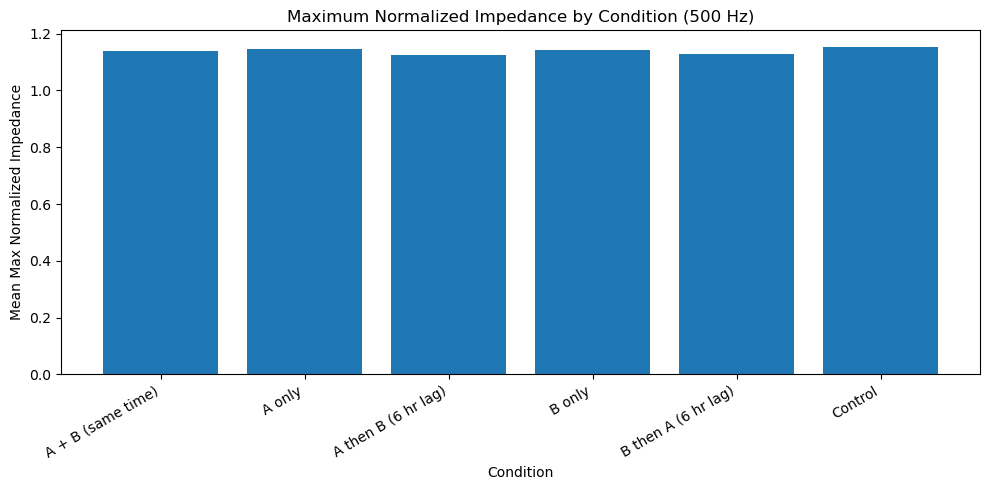

In [24]:
plt.figure(figsize=(10, 5))
plt.bar(condition_summary["Condition"], condition_summary["Mean_Max_Impedance"])

plt.xlabel("Condition")
plt.ylabel("Mean Max Normalized Impedance")
plt.title("Maximum Normalized Impedance by Condition (500 Hz)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 21. Plot Time of Maximum Response by Condition
This shows when each condition reaches its maximum normalized impedance.

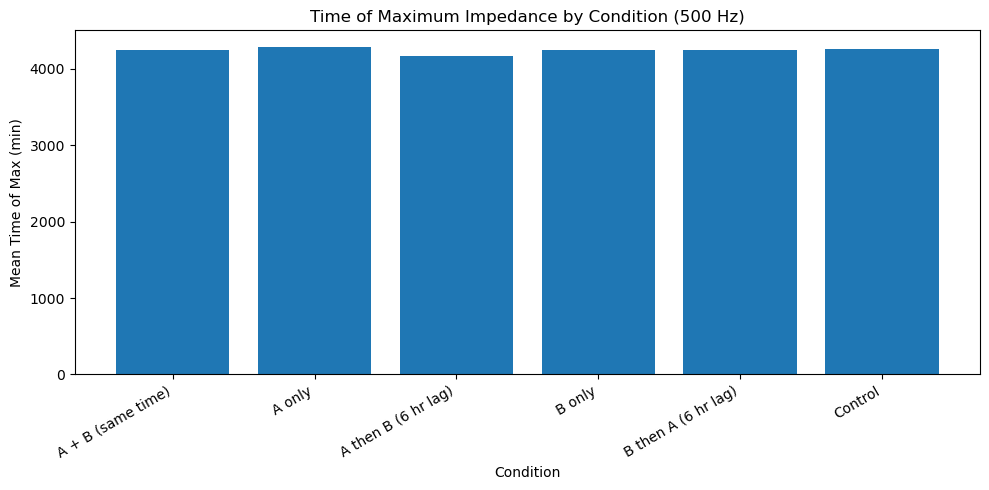

In [25]:
plt.figure(figsize=(10, 5))
plt.bar(condition_summary["Condition"], condition_summary["Mean_Time_of_Max"])

plt.xlabel("Condition")
plt.ylabel("Mean Time of Max (min)")
plt.title("Time of Maximum Impedance by Condition (500 Hz)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 22. Plot Growth Slope by Condition
This compares the approximate overall growth trend across conditions.

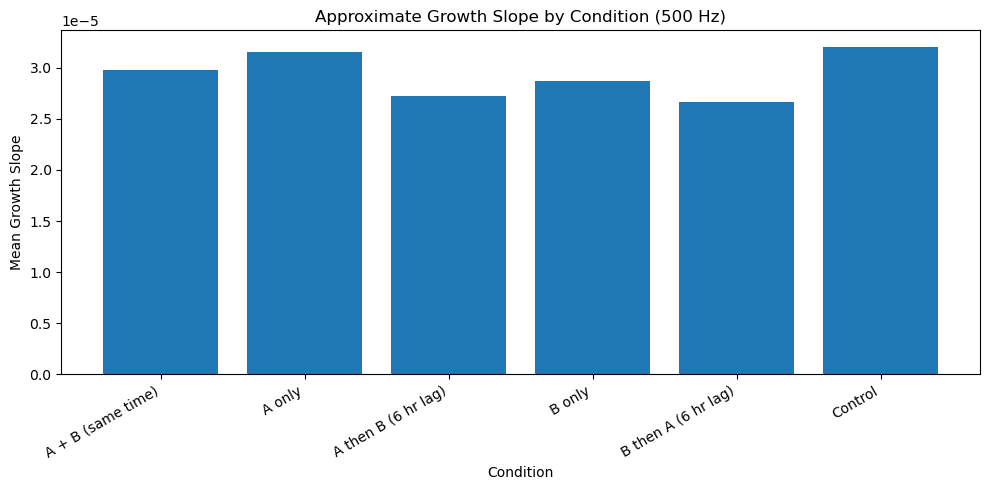

In [26]:
plt.figure(figsize=(10, 5))
plt.bar(condition_summary["Condition"], condition_summary["Mean_Slope"])

plt.xlabel("Condition")
plt.ylabel("Mean Growth Slope")
plt.title("Approximate Growth Slope by Condition (500 Hz)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 23. Overlay Mean Normalized Curves by Condition
Plot the average normalized 500 Hz curve for each condition to compare full time-course behavior.

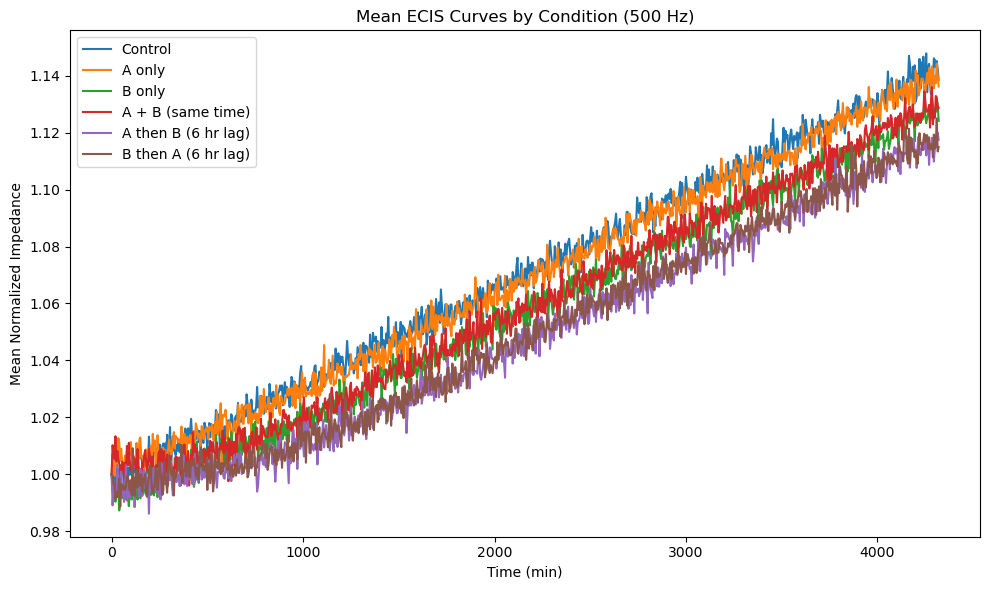

In [27]:
plt.figure(figsize=(10, 6))

for condition in metadata["Condition"].unique():
    condition_wells = metadata[metadata["Condition"] == condition]["file_path"]

    curves = []

    for file_name in condition_wells:
        df_well = pd.read_csv(f"{base_dir}/{file_name}")
        df_500 = df_well[df_well["Frequency_Hz"] == 500].copy()

        baseline = df_500["Impedance_Magnitude"].iloc[0]
        df_500["Normalized"] = df_500["Impedance_Magnitude"] / baseline

        curves.append(df_500["Normalized"].values)

    curves = np.array(curves)
    mean_curve = curves.mean(axis=0)
    time = df_500["Time_min"].values

    plt.plot(time, mean_curve, label=condition)

plt.xlabel("Time (min)")
plt.ylabel("Mean Normalized Impedance")
plt.title("Mean ECIS Curves by Condition (500 Hz)")
plt.legend()
plt.tight_layout()
plt.show()

## 24. Interpretation
This section summarizes the first condition-level comparison across the pilot ECIS wells.

In [28]:
condition_summary

,Condition,Mean_Max_Impedance,SD_Max_Impedance,Mean_Time_of_Max,SD_Time_of_Max,Mean_Final_Impedance,SD_Final_Impedance,Mean_Slope,SD_Slope
0,A + B (same time),1.139002,0.008053,4253.333333,50.083264,1.128749,0.003117,0.000030,7.214205e-07
1,A only,1.147437,0.002733,4290.000000,17.320508,1.136222,0.008291,0.000032,1.919230e-06
2,A then B (6 hr lag),1.125745,0.006603,4165.000000,21.794495,1.117496,0.009278,0.000027,2.147777e-06
3,B only,1.140840,0.007452,4250.000000,76.974022,1.124141,0.008685,0.000029,2.010385e-06
4,B then A (6 hr lag),1.127131,0.006490,4253.333333,98.149546,1.114934,0.004570,0.000027,1.057958e-06
5,Control,1.153978,0.000445,4261.666667,79.425017,1.138463,0.011512,0.000032,2.664749e-06


At this stage, the analysis has moved beyond a single control-style well and now compares all pilot conditions at 500 Hz.

The extracted feature table includes maximum normalized impedance, time of maximum response, final normalized impedance, and approximate growth slope for every well. These values were then summarized across technical replicates for each condition.

This provides the first condition-level comparison framework for evaluating the effects of dose, lag, and order in the pilot ECIS dataset.

The next step will be to repeat this comparison at additional frequencies and determine whether the same trends remain consistent across the multifrequency ECIS signal.